Calculated Critical Temperature(Tc):  303.95437255616787
Calculated Critical Pressure(Tc):  73.06800976083646
Calculated Critical Volume(Vc):  0.12801


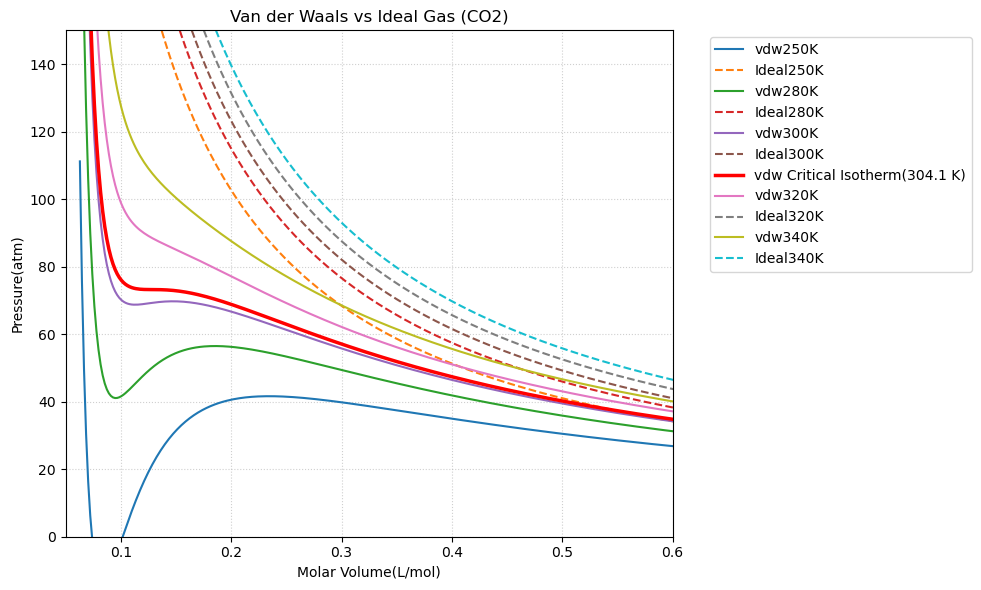

In [3]:
#Real Gases: Van der Waals Isotherms and Compressibility factor
import numpy as np
import matplotlib.pyplot as plt
#Universal gas constant and van der waals constants for CO2
R=0.08206
a=3.592
b=0.04267
Tc=(8*a)/(27*R*b)
Pc=a/(27*b**2)
Vc=3*b
print("Calculated Critical Temperature(Tc): ",Tc)
print("Calculated Critical Pressure(Tc): ",Pc)
print("Calculated Critical Volume(Vc): ",Vc)
#1.Van der Waals vs Ideal Gas Isotherms
V=np.linspace(b+0.02,1.0,500)
temperatures=[250,280,300,304.1,320,340]
plt.figure(figsize=(10,6))
for T in temperatures:
    #Van der Waals equintation:P=RT/(V-b)-a/V^2
    P_vdw=(R*T)/(V-b)-a/(V**2)
    P_ideal=(R*T)/V
    if(np.isclose(T,Tc,atol=0.5)):
        plt.plot(V,P_vdw,label=f"vdw Critical Isotherm({T} K)",color="red",linewidth=2.5)
    else:
        plt.plot(V,P_vdw,label=f"vdw{T}K")
        plt.plot(V,P_ideal,label=f"Ideal{T}K",linestyle="--")
plt.title("Van der Waals vs Ideal Gas (CO2)")
plt.xlabel("Molar Volume(L/mol)")
plt.ylabel("Pressure(atm)")
plt.ylim(0,150)
plt.xlim(0.05,0.6)
plt.grid(True,linestyle=":",alpha=0.6)
plt.legend(bbox_to_anchor=(1.05,1),loc="upper left")
plt.tight_layout()
plt.show()

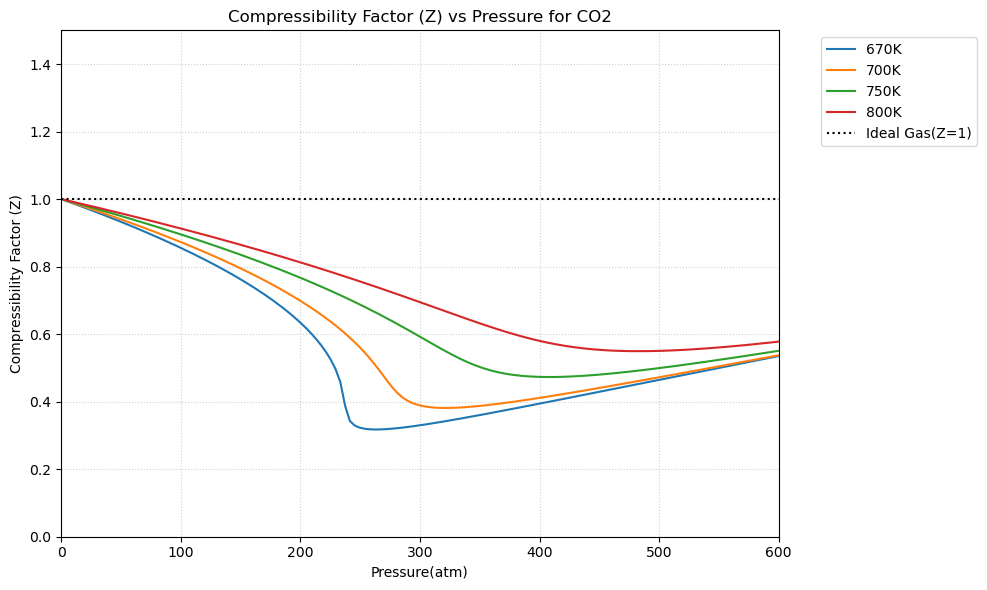

In [4]:
#2.Compressibility factor vs Pressure
T=315
a=5.5
b=0.03
R=0.08206
temperatures=[670,700,750,800]
plt.figure(figsize=(10,6))
for T in temperatures:
    pressures=np.linspace(1,2000,500)
    plt.xlim(0,2000)
    Z_values=[]
    for P in pressures:
        A=(a*P)/((R*T)**2)
        B=(b*P)/(R*T)
        roots=np.roots([1,-(1+B),A,-A*B])
        Z_values.append(np.max(roots[np.isreal(roots)].real))
    if(np.isclose(T,Tc,atol=0.5)):
        plt.plot(pressures,Z_values,label=f"vdw Critical{T} K",color="red",linewidth=2.5)
    else:
        plt.plot(pressures,Z_values,label=f"{T}K")
plt.axhline(1.0,color="black",linestyle=":",label="Ideal Gas(Z=1)")
plt.title("Compressibility Factor (Z) vs Pressure for CO2")
plt.xlabel("Pressure(atm)")
plt.ylabel("Compressibility Factor (Z)")
plt.ylim(0,1.5)
plt.xlim(0,600)
plt.grid(True,linestyle=":",alpha=0.6)
plt.legend(bbox_to_anchor=(1.05,1),loc="upper left")
plt.tight_layout()
plt.show()

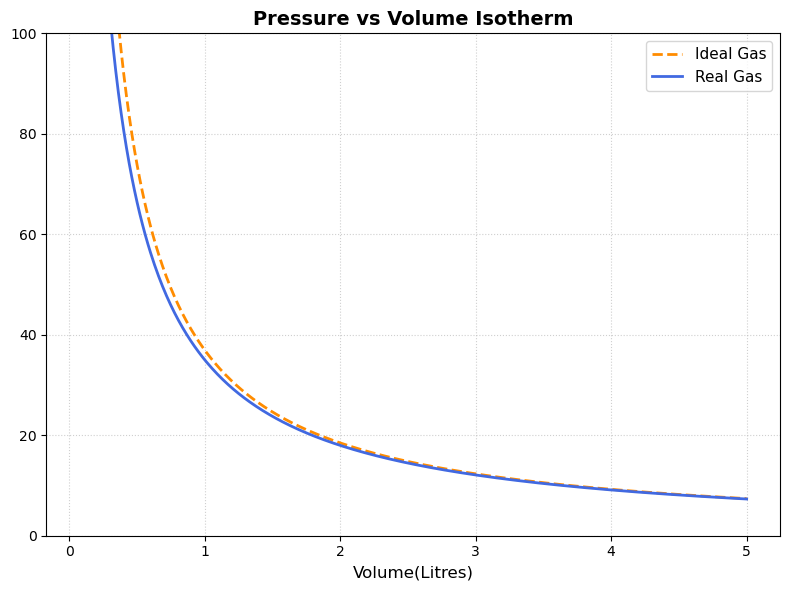

In [5]:
#3.Pressure vs volume plot
R=0.0821
n=1.0
T=450
a=3.59
b=0.0427
V=np.linspace(b*1.8,5.0,500)
#Ideal gas equation
P_ideal=(n*R*T)/V
#Van der Waals equation
P_real=(n*R*T)/(V-n*b)-(a*n**2)/(V**2)
plt.figure(figsize=(8,6),dpi=100)
plt.plot(V,P_ideal,label="Ideal Gas",color="darkorange",linestyle="--",linewidth=2)
plt.plot(V,P_real,label="Real Gas",color="royalblue",linewidth=2)
#Plot Graph
plt.title("Pressure vs Volume Isotherm",fontsize=14,fontweight="bold")
plt.xlabel("Volume(Litres)",fontsize=12)
plt.ylim(0,100)
plt.grid(True,linestyle=":",alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
#Display the plot inside jupyter
plt.show()

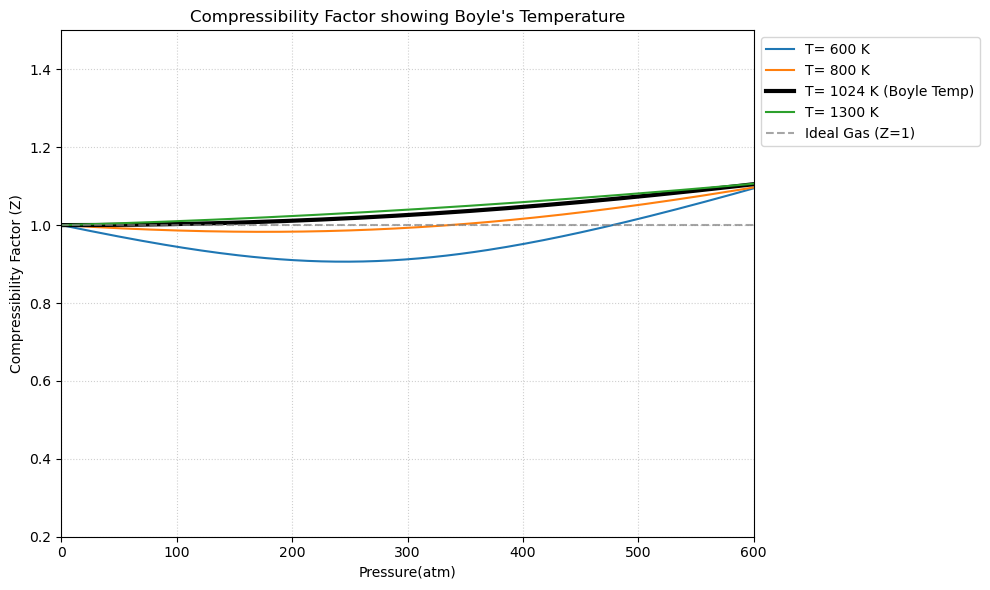

In [8]:
#4.Boyle's temperature plot
#Boyle's temperature
Tb=a/(R*b)
boyle_temperatures=[600,800,int(Tb),1300]
plt.figure(figsize=(10,6))
for T in boyle_temperatures:
    Z_values=[]
    for P in pressures:
        A=(a*P)/((R*T)**2)
        B=(b*P)/(R*T)
        #Solve the cubic equation for roots
        roots=np.roots([1,-(1+B),A,-A*B])
        #Largest real root
        real_roots=roots[np.isreal(roots)].real
        #Calculate Z
        Z=np.max(real_roots)
        Z_values.append(Z)
    if(int(T)==int(Tb)):
        plt.plot(pressures,Z_values,label=f"T= {T} K (Boyle Temp)",color="black",linewidth=3)
    else:
        plt.plot(pressures,Z_values,label=f"T= {T} K")
#Graph Styling
plt.axhline(1.0,color="gray",linestyle="--",alpha=0.7,label="Ideal Gas (Z=1)")
plt.title("Compressibility Factor showing Boyle's Temperature")
plt.xlabel("Pressure(atm)")
plt.ylabel("Compressibility Factor (Z)")
plt.xlim(0,600)
plt.ylim(0.2,1.5)
plt.grid(True,linestyle=":",alpha=0.6)
plt.legend(bbox_to_anchor=(1.0,1),loc="upper left")
plt.tight_layout()
plt.show()